### Content:
- compute average trip duration 
- plot number of trips per day
- plot count of number of trips for day of the week
- plot count of number of trips by hour of the day
- plot trips by hour for each operator: wind vs BIT e-scooters
- plot usage by month
- plot cumulative time of usage per day 



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [7]:
df = pd.read_parquet('../data/trips_pointv3.parquet')

In [8]:
df

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability
0,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 22:51:07+00:00,46.069058,11.125847,0,None
1,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 23:05:16+00:00,46.069185,11.125873,1,None
2,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 22:52:32+00:00,46.069980,11.123846,0,None
3,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 23:05:22+00:00,46.069166,11.125992,1,None
4,BIT,Bit Mobility,00002677-0000-1000-9537-5b7d6a617b60,2021-12-31 23:32:46+00:00,46.064904,11.123108,0,None
...,...,...,...,...,...,...,...,...
82751,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:18+00:00,46.060615,11.115260,53,None
82752,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:27+00:00,46.060804,11.114903,54,None
82753,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:38+00:00,46.060407,11.114829,55,None
82754,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:47+00:00,46.060273,11.114973,56,None


In [9]:
len(pd.unique(df.point_trip_id))

6475

### Average trip duration

In [10]:
new_df = df.groupby('point_trip_id', as_index=False).aggregate({"point_latitude": lambda x: x.to_list(),"point_longitude": lambda x: x.to_list(), "point_timestamp":lambda x: x.to_list()})
new_df["coords"] = [ [[k,v] for k,v in zip(i,j)] for i,j in zip(new_df["point_latitude"], new_df["point_longitude"])]
new_df

,point_trip_id,point_latitude,point_longitude,point_timestamp,coords
0,00000001-0000-1000-9ec1-5b7d6a617b60,"[46.097525, 46.079888, 46.073578, 46.094501]","[11.102425, 11.117030, 11.120929, 11.119510]","[2022-01-08 13:44:10+00:00, 2022-01-08 13:52:0...","[[46.097525, 11.102425], [46.079888, 11.117030..."
1,00000003-0000-1000-8e23-5b7d6a617b60,"[46.036368, 46.098608, 46.070222, 46.069969]","[11.130376, 11.119523, 11.120388, 11.123241]","[2022-02-01 21:01:50+00:00, 2022-02-01 21:30:5...","[[46.036368, 11.130376], [46.098608, 11.119523..."
2,00000008-0000-1000-8ba8-5b7d6a617b60,"[46.068406, 46.063910]","[11.123855, 11.123319]","[2022-02-17 06:37:18+00:00, 2022-02-17 06:40:1...","[[46.068406, 11.123855], [46.063910, 11.123319]]"
3,0000000d-0000-1000-892d-5b7d6a617b60,"[46.047552, 46.047170]","[11.129307, 11.132505]","[2022-01-07 21:12:24+00:00, 2022-01-07 21:16:0...","[[46.047552, 11.129307], [46.047170, 11.132505]]"
4,0000000f-0000-1000-9f9f-5b7d6a617b60,"[46.066372, 46.066397]","[11.117197, 11.117222]","[2022-01-29 13:18:43+00:00, 2022-01-29 13:19:2...","[[46.066372, 11.117197], [46.066397, 11.117222]]"
...,...,...,...,...,...
6470,fecd34f1-a711-46d8-ab96-f5f78af860c4,"[46.069033, 46.068907, 46.069093, 46.069159, 4...","[11.119162, 11.119182, 11.119231, 11.119275, 1...","[2022-02-16 18:54:24+00:00, 2022-02-16 18:54:3...","[[46.069033, 11.119162], [46.068907, 11.119182..."
6471,ff404691-af8e-4c59-a921-7684f499e38e,"[46.060748, 46.060657, 46.060701, 46.060906, 4...","[11.124904, 11.125375, 11.125289, 11.124777, 1...","[2022-01-18 11:57:44+00:00, 2022-01-18 11:57:5...","[[46.060748, 11.124904], [46.060657, 11.125375..."
6472,ff946a51-77b7-4231-809d-58d665ffe55c,"[46.069039, 46.069110, 46.069167, 46.068610, 4...","[11.126718, 11.127448, 11.127319, 11.125656, 1...","[2022-01-05 18:38:52+00:00, 2022-01-05 18:38:2...","[[46.069039, 11.126718], [46.069110, 11.127448..."
6473,ff9939d2-8a32-41e6-9c18-4082433f179a,"[46.074619, 46.074553, 46.074582, 46.074750, 4...","[11.124928, 11.124646, 11.124663, 11.124664, 1...","[2022-01-10 02:28:30+00:00, 2022-01-10 02:29:0...","[[46.074619, 11.124928], [46.074553, 11.124646..."


In [11]:
new_df.point_timestamp[0]

[Timestamp('2022-01-08 13:44:10+0000', tz='UTC'),
 Timestamp('2022-01-08 13:52:01+0000', tz='UTC'),
 Timestamp('2022-01-12 15:44:15+0000', tz='UTC'),
 Timestamp('2022-01-12 15:55:02+0000', tz='UTC')]

In [12]:
df[df.point_trip_id =='00000001-0000-1000-9ec1-5b7d6a617b60'] ## how is it that the same ID appears in different days? does it mean it's the same person?

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability
2934,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2022-01-08 13:44:10+00:00,46.097525,11.102425,0,None
2973,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2022-01-08 13:52:01+00:00,46.079888,11.117030,1,None
5093,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2022-01-12 15:44:15+00:00,46.073578,11.120929,0,None
5094,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2022-01-12 15:55:02+00:00,46.094501,11.119510,1,None


try differently: build dictionary with all timestamps per trip (some are different trips even if same id)

In [13]:
df

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability
0,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 22:51:07+00:00,46.069058,11.125847,0,None
1,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 23:05:16+00:00,46.069185,11.125873,1,None
2,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 22:52:32+00:00,46.069980,11.123846,0,None
3,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 23:05:22+00:00,46.069166,11.125992,1,None
4,BIT,Bit Mobility,00002677-0000-1000-9537-5b7d6a617b60,2021-12-31 23:32:46+00:00,46.064904,11.123108,0,None
...,...,...,...,...,...,...,...,...
82751,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:18+00:00,46.060615,11.115260,53,None
82752,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:27+00:00,46.060804,11.114903,54,None
82753,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:38+00:00,46.060407,11.114829,55,None
82754,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:47+00:00,46.060273,11.114973,56,None


In [14]:
d={}
for row in range(len(df)):
  if df.point_trip_id[row] not in d.keys():
    inner_df={}
    inner_df[df.point_sequence[row]]=df.point_timestamp[row]
    d[df.point_trip_id[row]] = inner_df
  else:
    if df.point_sequence[row] not in d[df.point_trip_id[row]]:
      d[df.point_trip_id[row]][df.point_sequence[row]]=df.point_timestamp[row]
    else:
      if df.point_trip_id[row]+'+1' not in d.keys():
        inner_df={}
        inner_df[df.point_sequence[row]]=df.point_timestamp[row]
        d[df.point_trip_id[row]+'+1'] = inner_df
      else:
        d[df.point_trip_id[row]+'+1'][df.point_sequence[row]]=df.point_timestamp[row]

In [15]:
# d={}
# for row in range(len(df)):
#   if df.point_trip_id[row] not in d.keys():
#     inner_df={}
#     inner_df[float(df.point_sequence[row])]=str(df.point_timestamp[row])
#     d[df.point_trip_id[row]] = inner_df
#   else:
#     if float(df.point_sequence[row]) not in d[df.point_trip_id[row]]:
#       d[df.point_trip_id[row]][float(df.point_sequence[row])]=str(df.point_timestamp[row])
#     else:
#       if df.point_trip_id[row]+'+1' not in d.keys():
#         inner_df={}
#         inner_df[float(df.point_sequence[row])]=str(df.point_timestamp[row])
#         d[df.point_trip_id[row]+'+1'] = inner_df
#       else:
#         d[df.point_trip_id[row]+'+1'][float(df.point_sequence[row])]=str(df.point_timestamp[row])



# import os
# import sys 
# from google.colab import drive 
# import glob

# path = "/content/drive" 
# drive.mount(path, force_remount=True)  
# data_path = "drive/MyDrive/Colab Notebooks" 

# myfiles = glob.glob(os.path.join(data_path, '*')) 
# print(myfiles)



# import json
    
# with open(data_path+'/all_trips_timestamps.json', 'w', encoding='utf-8') as file:
#   json.dump(d, file)

In [16]:
l=[]
for k in d.keys():
  duration = d[k][max(d[k].keys())] - d[k][min(d[k].keys())]
  l.append((k, duration))
l

[('00000f26-0000-1000-85d6-5b7d6a617b60', Timedelta('0 days 00:14:09')),
 ('00000f55-0000-1000-85f5-5b7d6a617b60', Timedelta('0 days 00:12:50')),
 ('00002677-0000-1000-9537-5b7d6a617b60', Timedelta('0 days 00:01:51')),
 ('000002e4-0000-1000-9784-5b7d6a617b60', Timedelta('0 days 00:11:00')),
 ('0000101c-0000-1000-a03c-5b7d6a617b60', Timedelta('0 days 00:18:42')),
 ('0000159e-0000-1000-a3de-5b7d6a617b60', Timedelta('0 days 00:02:38')),
 ('000018bd-0000-1000-a5ed-5b7d6a617b60', Timedelta('0 days 00:08:59')),
 ('000018ec-0000-1000-a60c-5b7d6a617b60', Timedelta('0 days 00:20:34')),
 ('00001fb7-0000-1000-8377-5b7d6a617b60', Timedelta('0 days 00:20:24')),
 ('00002073-0000-1000-83f3-5b7d6a617b60', Timedelta('0 days 00:03:29')),
 ('00002278-0000-1000-8548-5b7d6a617b60', Timedelta('0 days 00:19:23')),
 ('00000bee-0000-1000-902e-5b7d6a617b60', Timedelta('0 days 00:20:16')),
 ('0000204f-0000-1000-9d9f-5b7d6a617b60', Timedelta('0 days 00:09:35')),
 ('00001322-0000-1000-87a2-5b7d6a617b60', Timedelta

In [17]:
s=pd.Timedelta('0')
for el in l:
  s+=el[1]
avg=s/len(l)

print(avg)

print('The average trip is approximately %d minutes long.' % int((avg.seconds//60)%60))

0 days 00:09:29.929542023
The average trip is approximately 9 minutes long.


### Number of trips per day

In [18]:
d=[]
for row in range(len(df)):
  gg=df.point_timestamp[row].date()
  d.append(gg)
df['date']=d
df

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability,date
0,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 22:51:07+00:00,46.069058,11.125847,0,None,2021-12-31
1,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 23:05:16+00:00,46.069185,11.125873,1,None,2021-12-31
2,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 22:52:32+00:00,46.069980,11.123846,0,None,2021-12-31
3,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 23:05:22+00:00,46.069166,11.125992,1,None,2021-12-31
4,BIT,Bit Mobility,00002677-0000-1000-9537-5b7d6a617b60,2021-12-31 23:32:46+00:00,46.064904,11.123108,0,None,2021-12-31
...,...,...,...,...,...,...,...,...,...
82751,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:18+00:00,46.060615,11.115260,53,None,2022-02-21
82752,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:27+00:00,46.060804,11.114903,54,None,2022-02-21
82753,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:38+00:00,46.060407,11.114829,55,None,2022-02-21
82754,VENTO,Tier,58b1820b-61a1-4f28-8d56-c4f437b79c39,2022-02-21 23:48:47+00:00,46.060273,11.114973,56,None,2022-02-21


In [19]:
daily_trips = df.groupby('date', as_index=False).aggregate({"point_sequence": lambda x: x.to_list()})

cnt=[]
for el in range(len(daily_trips)):
  cnt.append(daily_trips.point_sequence[el].count(0))

daily_trips['num_trips']=cnt
daily_trips=daily_trips.drop(['point_sequence'], axis=1)
  
daily_trips.head()

,date,num_trips
0,2021-12-31,12
1,2022-01-01,97
2,2022-01-02,85
3,2022-01-03,118
4,2022-01-04,164


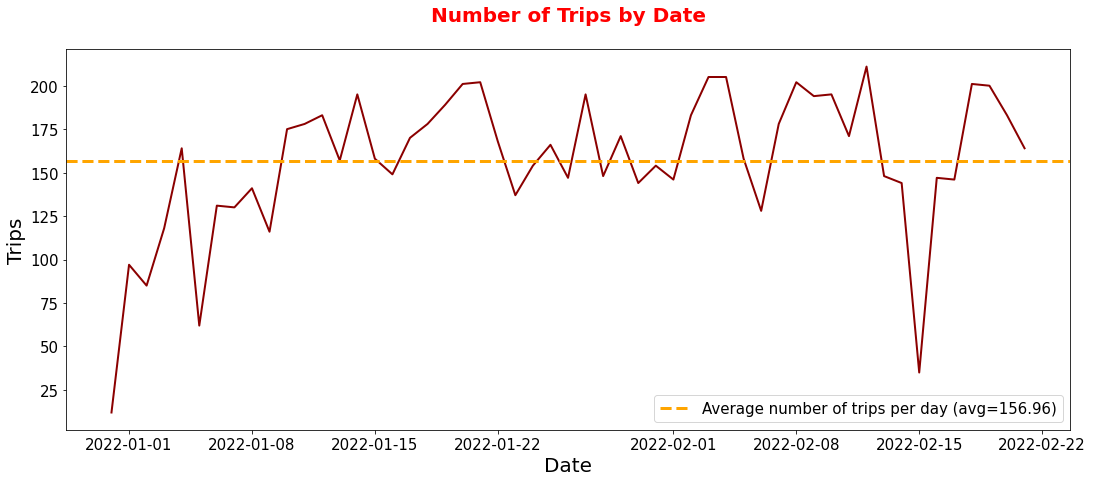

In [20]:
plt.figure(figsize = (18, 7))
plot = sns.lineplot(x = "date", y = "num_trips", data = daily_trips, color = "darkred", linewidth = 2)
avg_trips_num = daily_trips["num_trips"].mean()
plot.axhline(avg_trips_num, linestyle="--", color="orange", label="Average number of trips per day (avg="+str(round(avg_trips_num,2))+')', linewidth = 3) 
plt.title("Number of Trips by Date\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Date", size = 20, color = 'black')
plt.ylabel("Trips", size = 20, color = 'black')
plt.legend(prop={'size': 15})
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Number of trips by week day

In [21]:
df['day'] = df['point_timestamp'].dt.day_name()
df.head()

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability,date,day
0,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 22:51:07+00:00,46.069058,11.125847,0,None,2021-12-31,Friday
1,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 23:05:16+00:00,46.069185,11.125873,1,None,2021-12-31,Friday
2,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 22:52:32+00:00,46.069980,11.123846,0,None,2021-12-31,Friday
3,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 23:05:22+00:00,46.069166,11.125992,1,None,2021-12-31,Friday
4,BIT,Bit Mobility,00002677-0000-1000-9537-5b7d6a617b60,2021-12-31 23:32:46+00:00,46.064904,11.123108,0,None,2021-12-31,Friday


In [22]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
trip_by_weekday = df.groupby('day')['day'].agg(["count"]).reindex(days).reset_index()
trip_by_weekday.columns = ["day_of_week", "num_trips"]
trip_by_weekday

,day_of_week,num_trips
0,Monday,11222
1,Tuesday,10251
2,Wednesday,11655
3,Thursday,12686
4,Friday,12744
5,Saturday,13136
6,Sunday,11062


In [23]:
trip_by_weekday["num_trips"].mean()

11822.285714285714

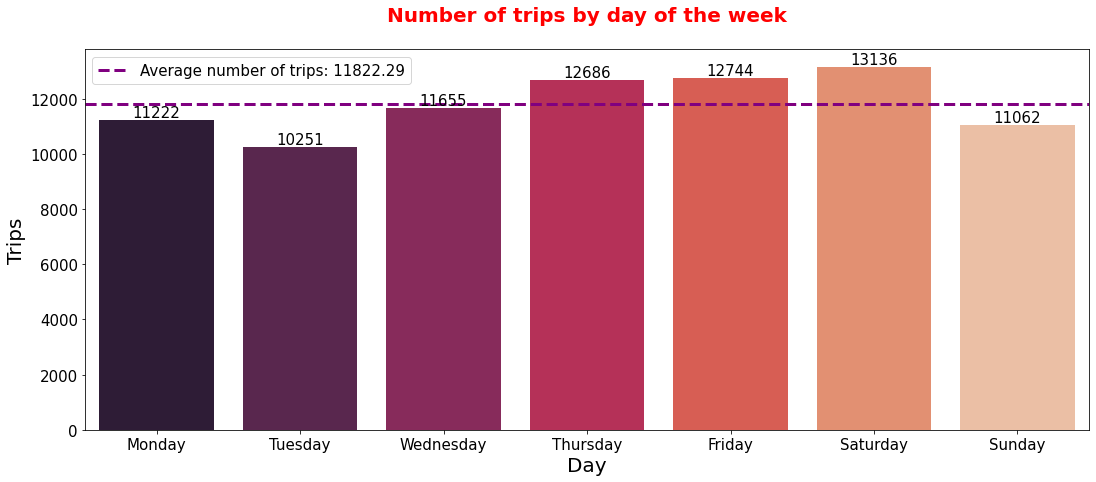

In [24]:
plt.figure(figsize = (18, 7))
plot = sns.barplot(x = "day_of_week", y = "num_trips", data = trip_by_weekday, palette = "rocket")
for p in plot.patches:
  plot.annotate('{:.0f}'.format(p.get_height()),
                (p.get_x()+0.4, p.get_height()),
                ha='center', va='bottom',color= 'black', size = 15)
plot.axhline(trip_by_weekday["num_trips"].mean(), linestyle="--", color="purple", label="Average number of trips: "+str(round(trip_by_weekday["num_trips"].mean(),2)), linewidth = 3) 
plt.title("Number of trips by day of the week\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Day", size = 20, color = 'black')
plt.ylabel("Trips", size = 20, color = 'black')
plt.legend(prop={'size': 15})
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Trips by hour of the day

In [25]:
df['hour'] = df['point_timestamp'].dt.hour

trip_by_h = df['hour'].value_counts().to_frame().reset_index()
trip_by_h.columns = ['hour', 'num_trips']

trip_by_h

,hour,num_trips
0,18,6904
1,15,6493
2,17,5962
3,11,5909
4,16,5580
5,14,5555
6,13,4757
7,12,4511
8,19,4371
9,10,3806


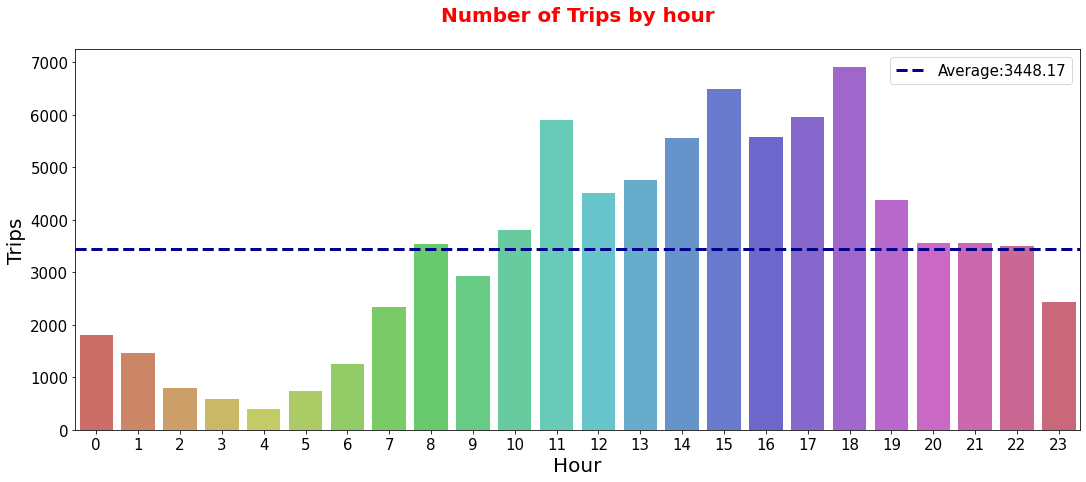

In [26]:
plt.figure(figsize = (18, 7))
plot = sns.barplot(x = 'hour', y = 'num_trips', data = trip_by_h, palette = "hls")
plot.axhline(trip_by_h['num_trips'].mean(), linestyle="--", color="darkblue", label="Average:"+str(round(trip_by_h['num_trips'].mean(), 2)), linewidth = 3) 
plt.title("Number of Trips by hour\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Hour", size = 20, color = 'black')
plt.ylabel("Trips", size = 20, color = 'black')
plt.legend(prop={'size': 15})
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.show()

### Number of trips by the two different operators

In [27]:
pd.unique(df.operator)

array(['BIT', 'VENTO'], dtype=object)

In [28]:
op = df.groupby(['operator', 'hour'])['operator'].agg(["count"]).reset_index()
op.columns = ['operator', 'hour', 'num_trips']
op

,operator,hour,num_trips
0,BIT,0,188
1,BIT,1,139
2,BIT,2,98
3,BIT,3,67
4,BIT,4,82
5,BIT,5,88
6,BIT,6,531
7,BIT,7,586
8,BIT,8,595
9,BIT,9,571


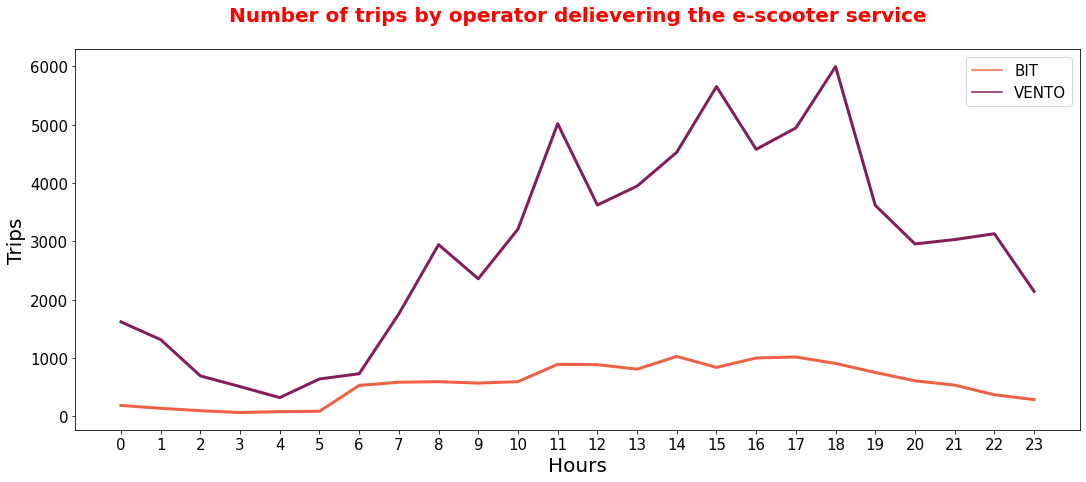

In [29]:
plt.figure(figsize = (18, 7))
sns.lineplot(x = 'hour', y = 'num_trips', hue = 'operator', data = op, palette = "rocket_r", linewidth = 3) 
plt.title("Number of trips by operator delievering the e-scooter service\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Hours", size = 20, color = "black")
plt.ylabel("Trips", size = 20, color = "black")
plt.legend(prop={'size': 15})
plt.xticks(range(0,24), size = 15)
plt.yticks(size = 15)
plt.show()

### Usage by month

In [30]:
df['month'] = pd.to_datetime(df['date']).dt.month
df.head()

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability,date,day,hour,month
0,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 22:51:07+00:00,46.069058,11.125847,0,None,2021-12-31,Friday,22,12
1,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 23:05:16+00:00,46.069185,11.125873,1,None,2021-12-31,Friday,23,12
2,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 22:52:32+00:00,46.069980,11.123846,0,None,2021-12-31,Friday,22,12
3,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 23:05:22+00:00,46.069166,11.125992,1,None,2021-12-31,Friday,23,12
4,BIT,Bit Mobility,00002677-0000-1000-9537-5b7d6a617b60,2021-12-31 23:32:46+00:00,46.064904,11.123108,0,None,2021-12-31,Friday,23,12


In [31]:
m = df.groupby(['month', 'hour'])['month'].agg(["count"]).reset_index()
m.columns = ['month', 'hour', 'num_trips']
m.head()

,month,hour,num_trips
0,1,0,903
1,1,1,830
2,1,2,451
3,1,3,374
4,1,4,224


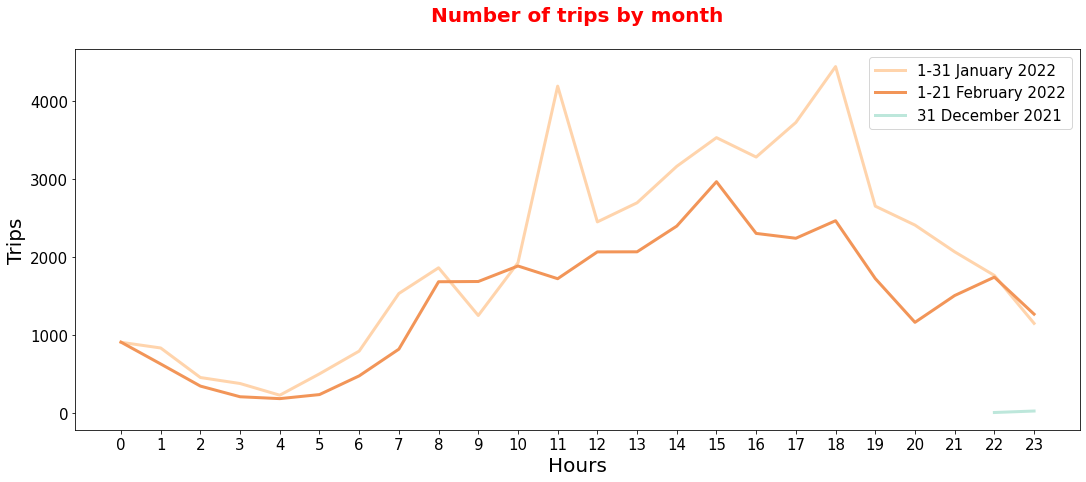

In [32]:
plt.figure(figsize = (18, 7))
sns.lineplot(x = 'hour', y = 'num_trips', hue = 'month', data = m, palette = "icefire_r", linewidth = 3) 
plt.title("Number of trips by month\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Hours", size = 20, color = "black")
plt.ylabel("Trips", size = 20, color = "black")
plt.legend(['1-31 January 2022', '1-21 February 2022', '31 December 2021'], prop={'size': 15})
plt.xticks(range(0,24), size = 15)
plt.yticks(size = 15)
plt.show()

### Cumulative time of usage per day

(may add cumulative time of usage per day **per scooter**)

In [33]:
df['day'] = pd.to_datetime(df['date']).dt.day
df.head()

,operator,point_operator_id,point_trip_id,point_timestamp,point_latitude,point_longitude,point_sequence,point_reliability,date,day,hour,month
0,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 22:51:07+00:00,46.069058,11.125847,0,None,2021-12-31,31,22,12
1,BIT,Bit Mobility,00000f26-0000-1000-85d6-5b7d6a617b60,2021-12-31 23:05:16+00:00,46.069185,11.125873,1,None,2021-12-31,31,23,12
2,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 22:52:32+00:00,46.069980,11.123846,0,None,2021-12-31,31,22,12
3,BIT,Bit Mobility,00000f55-0000-1000-85f5-5b7d6a617b60,2021-12-31 23:05:22+00:00,46.069166,11.125992,1,None,2021-12-31,31,23,12
4,BIT,Bit Mobility,00002677-0000-1000-9537-5b7d6a617b60,2021-12-31 23:32:46+00:00,46.064904,11.123108,0,None,2021-12-31,31,23,12


In [34]:
d={}
for row in range(len(df)):
  if df.point_trip_id[row] not in d.keys():
    inner_df={}
    inner_df[df.point_sequence[row]]=df.point_timestamp[row]
    d[df.point_trip_id[row]] = inner_df
  else:
    if df.point_sequence[row] not in d[df.point_trip_id[row]]:
      d[df.point_trip_id[row]][df.point_sequence[row]]=df.point_timestamp[row]
    else:
      if df.point_trip_id[row]+'+1' not in d.keys():
        inner_df={}
        inner_df[df.point_sequence[row]]=df.point_timestamp[row]
        d[df.point_trip_id[row]+'+1'] = inner_df
      else:
        d[df.point_trip_id[row]+'+1'][df.point_sequence[row]]=df.point_timestamp[row]

# for each trip, record date and trip duration
duration=[]
day=[]
for k in d.keys():
  duration.append(d[k][max(d[k].keys())] - d[k][min(d[k].keys())])
  day.append(pd.to_datetime(d[k][0]).date())

drtn = pd.DataFrame({'day':day, 'duration':duration})
drtn

,day,duration
0,2021-12-31,0 days 00:14:09
1,2021-12-31,0 days 00:12:50
2,2021-12-31,0 days 00:01:51
3,2021-12-31,0 days 00:11:00
4,2021-12-31,0 days 00:18:42
...,...,...
7943,2022-02-21,0 days 00:02:07
7944,2022-02-21,0 days 00:06:12
7945,2022-02-21,0 days 00:03:39
7946,2022-02-21,0 days 00:10:28


In [35]:
# cumulative duration of trips, for each date
drtn_by_day = drtn.groupby(['day'])['duration'].agg(["sum"]).reset_index()
drtn_by_day.columns = ['day', 'cumduration']
drtn_by_day.head()

,day,cumduration
0,2021-12-31,0 days 02:34:15
1,2022-01-01,0 days 19:00:40
2,2022-01-02,0 days 12:44:09
3,2022-01-03,0 days 23:21:37
4,2022-01-04,1 days 00:31:27


In [36]:
drtn_by_day['cumduration_time']=(pd.Timestamp('now').normalize() + drtn_by_day.cumduration).dt.time # pd.Timestamp('now').normalize() -> reset to midnight

In [37]:
drtn_by_day['cumduration_int'] = round(drtn_by_day.cumduration.dt.seconds / 60, 0)
drtn_by_day['cumduration_int'] = drtn_by_day['cumduration_int'].astype('int64', copy=False)
drtn_by_day.head()

,day,cumduration,cumduration_time,cumduration_int
0,2021-12-31,0 days 02:34:15,02:34:15,154
1,2022-01-01,0 days 19:00:40,19:00:40,1141
2,2022-01-02,0 days 12:44:09,12:44:09,764
3,2022-01-03,0 days 23:21:37,23:21:37,1402
4,2022-01-04,1 days 00:31:27,00:31:27,31


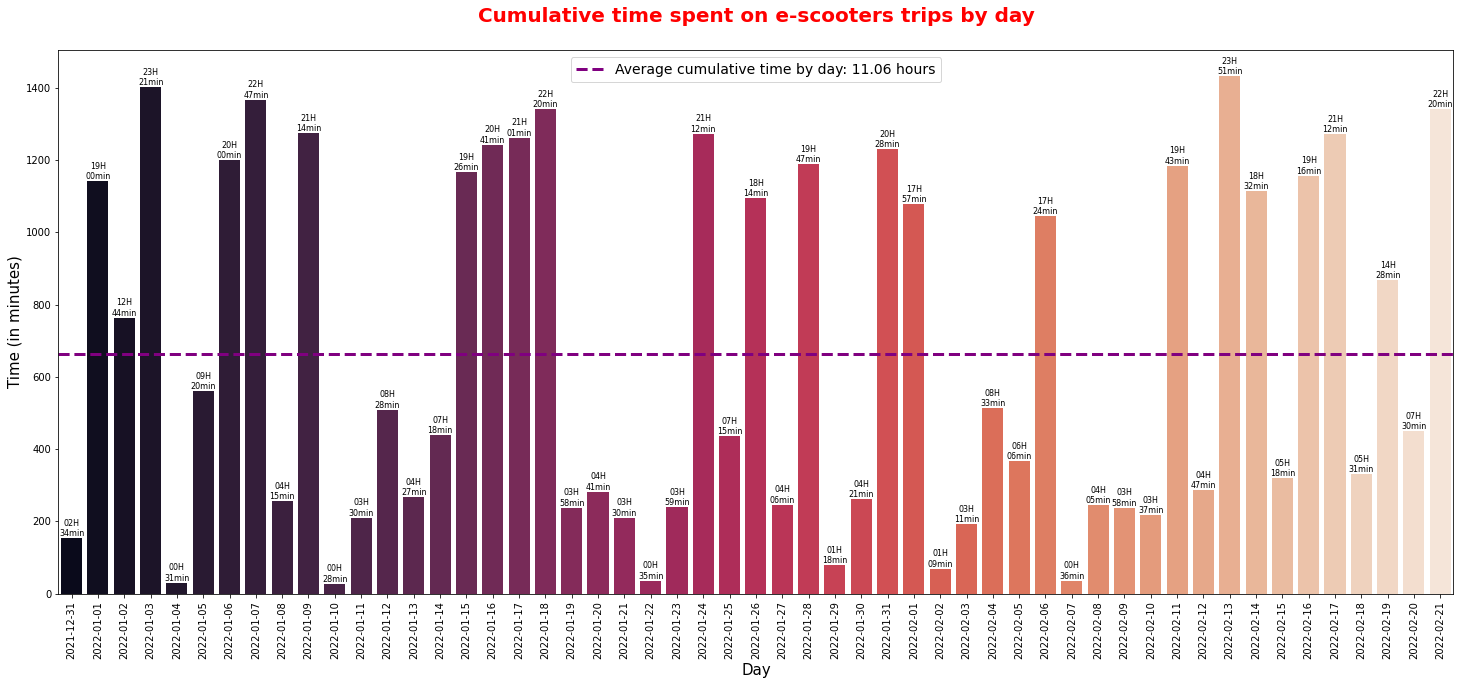

In [38]:
plt.figure(figsize = (25, 10))
plot = sns.barplot(x = "day", y = "cumduration_int", data = drtn_by_day, palette = "rocket")
for p in range(len(plot.patches)):
  plot.annotate(str(drtn_by_day.cumduration_time[p])[:2]+'H\n'+str(drtn_by_day.cumduration_time[p])[3:5]+'min', 
                (plot.patches[p].get_x()+0.4, plot.patches[p].get_height()),
                ha='center', va='bottom',color= 'black', size = 8)
plot.axhline(drtn_by_day["cumduration_int"].mean(), linestyle="--", color="purple", label="Average cumulative time by day: "+str(round(drtn_by_day["cumduration_int"].mean()/60,2))+' hours', linewidth = 3) 
plt.title("Cumulative time spent on e-scooters trips by day\n", size = 20, color = "red", weight = "bold")
plt.xlabel("Day", size = 15, color = 'black')
plt.ylabel("Time (in minutes)", size = 15, color = 'black')
plt.legend(prop={'size': 14}, loc='upper center')
plt.xticks(size = 10, rotation=90)
plt.yticks(size = 10)
plt.show()